## Baseline: Metropolis Monte Carlo for a 1D potential

Before implementing event-chain methods, we first consider a simple Metropolis sampler for a one-dimensional target distribution

$$
\pi(x) \propto e^{-x^2}.
$$

This corresponds to the potential

$$
U(x)=x^2
$$

at temperature $T=1$. The purpose of this example is to provide a simple baseline for understanding proposal size, acceptance rate, burn-in, and sample autocorrelation.

In [1]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random

# set random seed for reproducibility
random.seed(42)

In [2]:
def potential(x):
    """
    Calculate the potential energy at a given position.

    Args:
        x (float): The position at which to calculate the potential energy.

    Returns:
        float: The potential energy at the given position.
    """
    return x**2

def potential_difference(current_x, proposed_x, single=True, double=False):
    """
    Calculate the difference in potential energy between the current and proposed positions.

    Args:
        current_x (float): The current position.
        proposed_x (float): The proposed position.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        float: The difference in potential energy between the two positions.
    """
    if single:
        return potential(proposed_x) - potential(current_x)
    if double: 
        return U_double_well(proposed_x) - U_double_well(current_x)
    else:
        raise ValueError("Either 'single' or 'double' must be True.")

In [3]:
def propose_move(current_x, proposal_width):
    """_summary_

    Args:
        current_x (float): The current position.
        proposal_width (float): The width of the proposal distribution.

    Returns:
        float: The proposed position.
    """
    noise = random.uniform(-proposal_width / 2, proposal_width / 2)
    return current_x + noise

In [4]:
def accept_move(delta_potential, temperature):
    """
    Calculate whether to accept a proposed move.

    Args:
        delta_potential (float): The difference in potential energy between the current and proposed positions.
        temperature (float): The temperature of the system.
    Returns:
        bool: True if the proposed move should be accepted, False otherwise.
    """
    acceptance_prob = min(1, np.exp(-delta_potential / temperature))
    return np.random.rand() < acceptance_prob

In [5]:
def metropolis_step(current_x, proposal_width, temperature, single=True, double=False):
    """
    Perform a single Metropolis step.

    Args:
        current_x (float): The current position.
        proposal_width (float): The width of the proposal distribution.
        temperature (float): The temperature of the system.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        tuple: A tuple containing the new position after the Metropolis step and a boolean indicating whether the move was accepted.
    """
    proposed_x = propose_move(current_x, proposal_width)
    delta_potential = potential_difference(current_x, proposed_x, single=single, double=double)
    
    accepted = accept_move(delta_potential, temperature)
    return (proposed_x, True) if accepted else (current_x, False)

def metropolis_run(initial_x, num_steps, proposal_width, temperature, single=True, double=False):
    """
    Run the Metropolis algorithm for a given number of steps.   

    Args:
        initial_x (float): The initial position of the system.
        num_steps (int): The number of steps to run the algorithm.
        proposal_width (float): The width of the proposal distribution.
        temperature (float): The temperature of the system.
        single (bool): Whether to use a single well potential.
        double (bool): Whether to use a double well potential.

    Returns:
        tuple: A tuple containing an array of positions visited during the simulation and the acceptance rate.
    """

    positions = [initial_x]
    current_x = initial_x
    accepted_moves = 0
    
    for _ in range(num_steps):
        current_x, accepted = metropolis_step(current_x, proposal_width, temperature, single=single, double=double)
        
        if accepted:
            accepted_moves += 1
            
        positions.append(current_x)
        
    acceptance_rate = accepted_moves / num_steps
    
    return np.array(positions), acceptance_rate

In [6]:
def plot_trajectory_and_histogram(trajectory, acceptance_rate, burn_in, potential_func, title_suffix):
    """
    Plot the trajectory and histogram of sampled positions for a given trajectory.

    Args:
        trajectory (np.ndarray): The trajectory of positions.
        acceptance_rate (float): The acceptance rate of the Metropolis algorithm.
        burn_in (int): The number of initial steps to discard as burn-in.
        potential_func (callable): The potential function to plot the theoretical distribution.
        title_suffix (str): Suffix to add to the plot titles for differentiation.
    """
    samples = trajectory[burn_in:]

    plt.figure(figsize=(12, 8))
    plt.plot(trajectory)
    plt.axvline(burn_in, linestyle="--", label="Burn-in cutoff")
    plt.xlabel("Step")
    plt.ylabel("Position")
    plt.title(f"Metropolis trajectory {title_suffix}, acceptance rate = {acceptance_rate:.3f}")
    plt.grid()
    plt.legend()
    plt.show()

    x = np.linspace(-5, 5, 1000)
    
    plt.figure(figsize=(12, 8))
    plt.hist(samples, bins=50, density=True, alpha=0.7, label="Sampled distribution")
    plt.plot(x, np.exp(-potential_func(x)), color='red', label="Theoretical distribution")
    plt.xlabel("Position")
    plt.ylabel("Probability Density")
    plt.title(f"Histogram of sampled positions {title_suffix}")
    plt.grid()
    plt.legend()
    plt.show()

Acceptance Rate: 72.85%


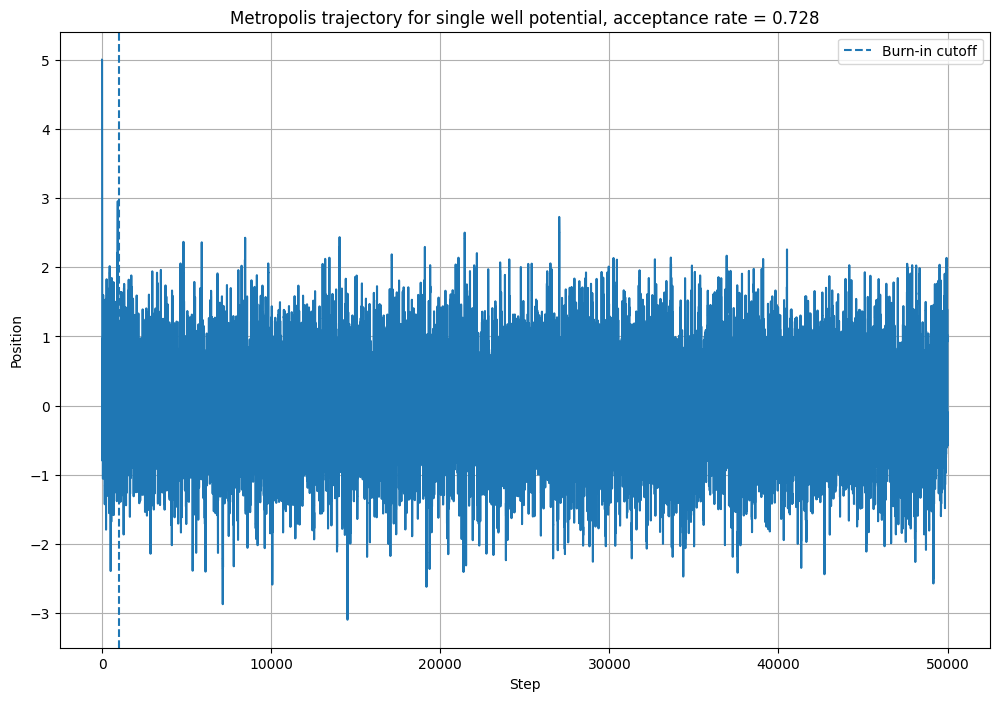

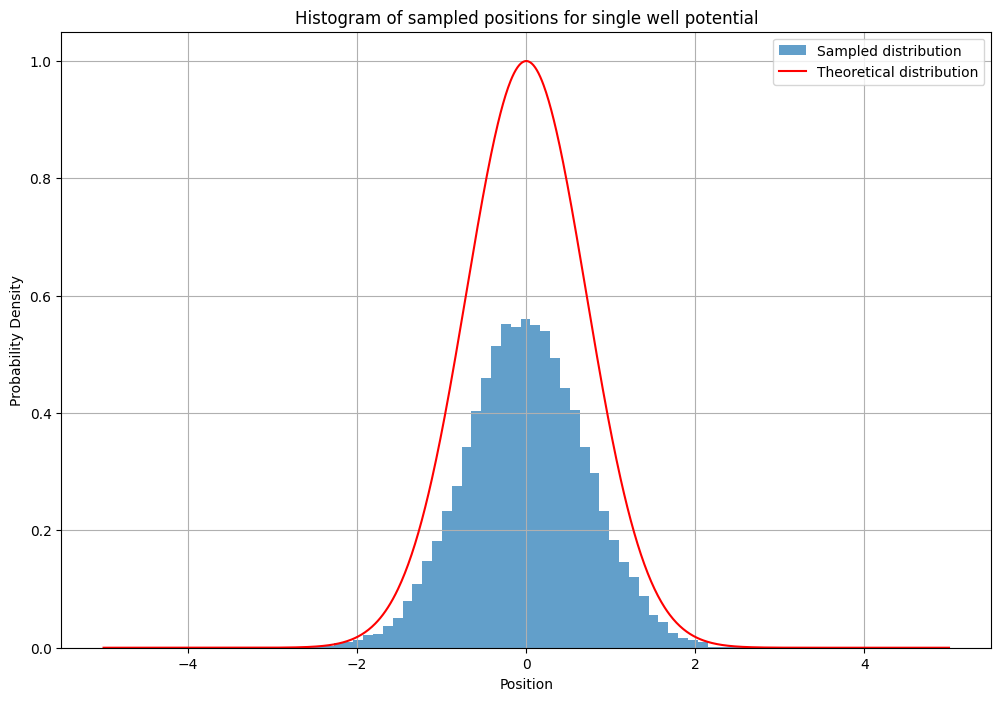

In [7]:
trajectory, acceptance_rate = metropolis_run(
    initial_x=5.0,
    num_steps=50_000,
    proposal_width=2,
    temperature=1.0,
)
print(f"Acceptance Rate: {acceptance_rate:.2%}")

burn_in = 1000

plot_trajectory_and_histogram(trajectory, acceptance_rate, burn_in, potential, "for single well potential")

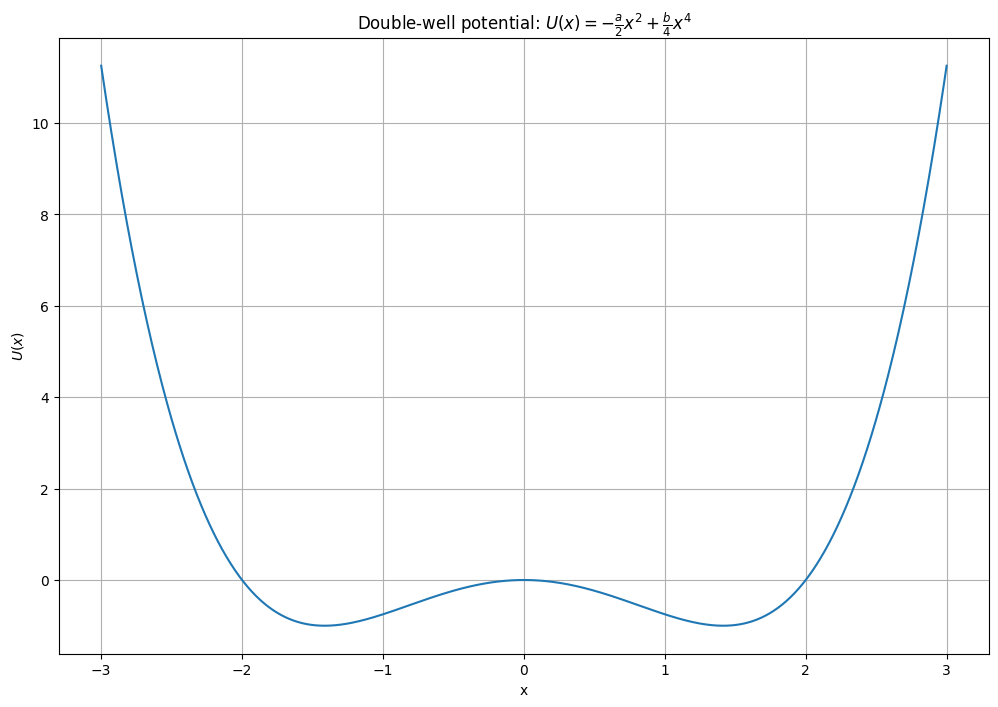

In [8]:
def U_double_well(x, a=2.0, b=1.0):
    """
    Calculate the potential energy for a double well potential at a given position.

    Args:
        x (float): The position at which to calculate the potential energy.
        a (float): The depth of the wells.
        b (float): The barrier height.
    """
    return -(a/2)*x**2 + (b/4)*x**4

x = np.linspace(-3, 3, 1000)

plt.figure(figsize=(12, 8))
plt.plot(x, U_double_well(x))
plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title(r"Double-well potential: $U(x)= -\frac{a}{2}x^{2} + \frac{b}{4}x^{4}$")
plt.grid()
plt.show()

### Double-well potential

We consider

$$U(x) = -\frac{ax^2}{2} + \frac{bx^4}{4}$$

with $a = 2$ and $b = 1$. This potential has two minima at $x = \pm \sqrt{2}$ and a potential barrier at $x = 0$.

Acceptance Rate: 85.90%


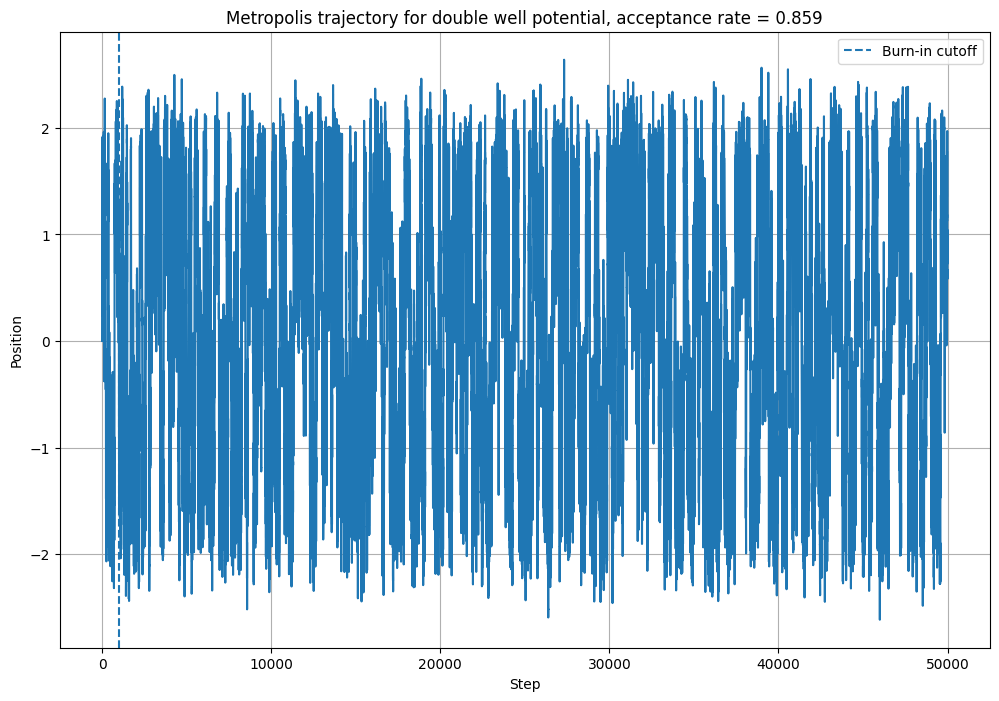

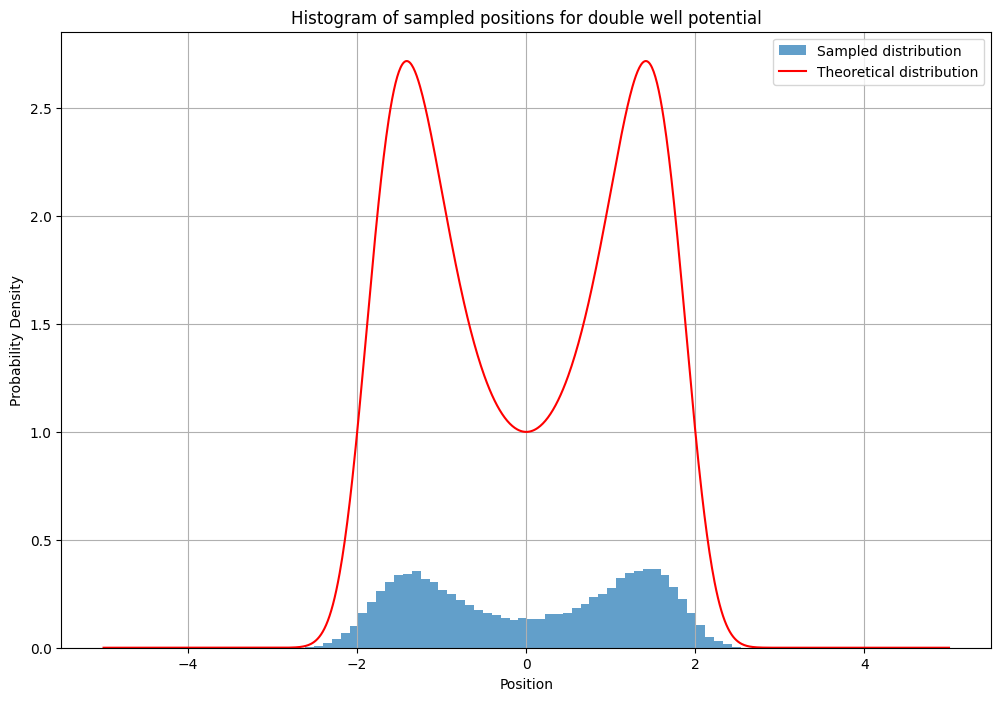

In [9]:
trajectory_double, acceptance_rate_double = metropolis_run(
    initial_x=0.0,
    num_steps=50000,
    proposal_width=1.0,
    temperature=1.0,
    single=False,
    double=True
)

print(f"Acceptance Rate: {acceptance_rate_double:.2%}")

plot_trajectory_and_histogram(trajectory_double, acceptance_rate_double, burn_in, U_double_well, "for double well potential")